# 4 Pre-Processing and Training Data<a id='4_Pre-Processing_and_Training_Data'></a>

## 4.1 Contents<a id='4.1_Contents'></a>
* [4 Pre-Processing and Training Data](#4_Pre-Processing_and_Training_Data)
  * [4.1 Contents](#4.1_Contents)
  * [4.2 Introduction](#4.2_Introduction)
  * [4.3 Imports](#4.3_Imports)
  * [4.4 Load Data](#4.4_Load_Data)
  * [4.5 Principal Components Analysis](#4.5_Principal_Components_Analysis)
  * [4.6 Train/Test Split](#4.6_Train/Test_Split)
  * [4.7 Scale Dataset](#4.7_Scale_Dataset)
  * [4.8 Linear Regression Models](#4.8_Ordinary_Least_Squares_Model)
  * [4.9 Random Forest Model](#4.10_Random_Forest_Model)
  * [4.10 Final Model Selection](#4.11_Final_Model_Selection)
  * [4.11 Conclusion](#4.11_Conclusion)
  * [4.13 Save best model object from pipeline](#4.13_Save_best_model_object_from_pipeline)
  * [4.14 Summary](#4.14_Summary)


## 4.2 Introduction<a id='4.2_Introduction'></a>

In the preceding notebooks, we performed exploratory data analysis and determined the features and overall dataset to be used for modeling. We found some missing data for co2, gdp, energy_per_capita features that we handled by dropping the countries entirely or backfilling data for 1 to 2 years.

In this notebook we will do PCA analysis and finalize our feature set, create train/test sets, standardize our data and start building some machine learning models. 

## 4.3 Imports<a id='4.3_Imports'></a>

In [47]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import __version__ as sklearn_version
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, learning_curve, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
import statsmodels.api as sm
import statsmodels.formula.api as smf
import datetime
from library.sb_utils import save_file

## 4.4 Load Data<a id='4.4_Load_Data'></a>

In [2]:
co2_data = pd.read_csv('../data/processed/model_ready_data.csv')
co2_data.head()

,country,year,iso_code,log_co2,log_gdp_per_capita,log_energy_per_capita,log_population
0,Afghanistan,1990,AFG,0.705076,6.989063,7.826789,16.304215
1,Afghanistan,1991,AFG,0.649195,6.891983,6.928611,16.320128
2,Afghanistan,1992,AFG,0.393393,6.861405,6.426577,16.401693
3,Afghanistan,1993,AFG,0.396761,6.489406,6.302176,16.519765
4,Afghanistan,1994,AFG,0.374318,6.188986,6.182800,16.603653


In [3]:
co2_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4853 entries, 0 to 4852
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   country                4853 non-null   object 
 1   year                   4853 non-null   int64  
 2   iso_code               4853 non-null   object 
 3   log_co2                4853 non-null   float64
 4   log_gdp_per_capita     4853 non-null   float64
 5   log_energy_per_capita  4853 non-null   float64
 6   log_population         4853 non-null   float64
dtypes: float64(4), int64(1), object(2)
memory usage: 265.5+ KB


In [4]:
co2_data['year']=co2_data['year'].astype(str)

## 4.5 Principal Components Analysis<a id='4.5_Principal_Components_Analysis'></a>

In [5]:
#preparing and scaling data for PCA Analysis
features = ['log_gdp_per_capita','log_energy_per_capita','log_population']
X=co2_data[features].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
#perform PCA Analysis
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

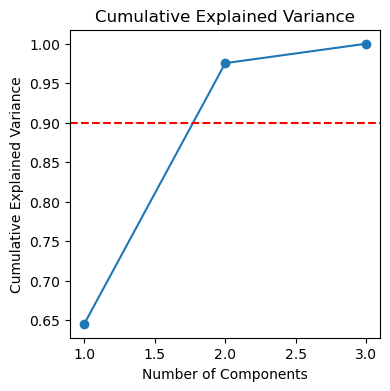

In [7]:
#Cumulative variance plot for PCA Components
cum_var = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize = (4,4))
plt.plot(range(1, len(features)+1), cum_var, marker='o')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(0.9, linestyle='--', color='red')
plt.show()

In [8]:
#pca data summary
pca_dataset = pd.DataFrame(pca.components_, columns=features, 
                            index =[f'PC{i+1}' for i in range(len(features))])
pca_dataset

,log_gdp_per_capita,log_energy_per_capita,log_population
PC1,0.702235,0.704213,-0.104641
PC2,0.093083,0.054901,0.994144
PC3,-0.705834,0.707863,0.026997


We can see from the cumulative explained variance plot and PCA components summary above that PC1 component accounts for more than 70% of the expalined variance and it represents the overall economic and energy development per capita. PC2 seems to be entirely driven by population size and PC3 represents the contrast between energy and gdp per capita.

We did PCA Analysis to understand if we could use PCA components instead of our log features for modeling. Our first PCA component seems to capture majority of the variance pointing to the strong combination of economic and energy features. Our goal is to provide meaningful insights into the drivers of CO2 emissions. Hence, we will not be using PCA components for modeling due to loss of interpretability of key drivers. Multicollinearity was found to be within an acceptable range based on VIF analysis done in exploratory data analysis notebook. Hence, we will proceed with our log features for modeling instead of PCA components.

## 4.6 Train/Test Split<a id='4.6_Train/Test_Split'></a>

Our data is partitioned on country/year and hence we will have to do a time based split for the train and test sets

In [13]:
train = co2_data[co2_data['year']<='2015'].copy()
test = co2_data[co2_data['year']>'2015'].copy()
X_train = train[features]
y_train = train['log_co2']
X_test = test[features]
y_test = test['log_co2']

In [14]:
X_train.shape, X_test.shape

((4205, 3), (648, 3))

In [15]:
y_train.shape, y_test.shape

((4205,), (648,))

In [16]:
#Check the `dtypes` attribute of `X_train` and 'X_test to verify all features are numeric
X_train.dtypes
X_test.dtypes

log_gdp_per_capita       float64
log_energy_per_capita    float64
log_population           float64
dtype: object

## 4.7 Scale Dataset<a id='4.7_Scale_Dataset'></a>

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [38]:
# creating dataframes from the scaled arrays
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=features, index = train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=features, index = test.index)

#Add fixed effect columns to the datasets
X_train_scaled_df['country'] = train['country']
#X_train_scaled_df['year'] = train['year']
X_train_scaled_df['log_co2'] = train['log_co2']

X_test_scaled_df['country'] = test['country']
#X_test_scaled_df['year'] = test['year']
X_test_scaled_df['log_co2'] = test['log_co2']

## 4.8 Linear Regression Models<a id='4.8_Linear_Regression_Models'></a>

##### 4.8.1.1.4 Train the model on the train split<a id='4.8.1.1.4_Train_the_model_on_the_train_split'></a>

In [39]:
#fixed effect ols model without cv
#fit the ols model
ols_model = smf.ols('log_co2 ~ log_population + log_gdp_per_capita + log_energy_per_capita + C(country)', data = X_train_scaled_df).fit()

In [40]:
#predict the model
test['ols_pred_scaled'] = ols_model.predict(X_test_scaled_df)

In [41]:
#evaluate results
rmse = np.sqrt(mean_squared_error(X_test_scaled_df['log_co2'],test['ols_pred_scaled']))
print(rmse)

0.2608433614678682


In [30]:
#fixed effect ols model with cv
tscv = TimeSeriesSplit(n_splits = 5)
ols_rmse_scores = []

#run manual cross validation loop
for train_idx, val_idx in tscv.split(co2_data):
    train_cv = co2_data.iloc[train_idx]
    val_cv = co2_data.iloc[val_idx]
    scaler = StandardScaler()
    X_train_scaled_cv = scaler.fit_transform(train_cv[features])
    X_val_scaled_cv = scaler.transform(val_cv[features])

    train_scaled_df = pd.DataFrame(X_train_scaled_cv, columns=features, index = train_cv.index)
    val_scaled_df = pd.DataFrame(X_val_scaled_cv, columns=features, index = val_cv.index)

    #add back fixed effect columns
    #train_scaled_df['country'] = train_cv['country']
    #train_scaled_df['year'] = train_cv['year']
    train_scaled_df['log_co2'] = train_cv['log_co2']

    #val_scaled_df['country'] = val_cv['country']
    #val_scaled_df['year'] = val_cv['year']
    val_scaled_df['log_co2'] = val_cv['log_co2']

    scaled_ols_model = smf.ols('log_co2 ~ log_population + log_gdp_per_capita + log_energy_per_capita', data = train_scaled_df).fit()
    preds = scaled_ols_model.predict(val_scaled_df)
    rmse = np.sqrt(mean_squared_error(val_scaled_df['log_co2'],preds))
    ols_rmse_scores.append(rmse)
    print("OLS CV RMSE:", ols_rmse_scores)
    print("Average:", np.mean(ols_rmse_scores))

OLS CV RMSE: [np.float64(0.46452889223883237)]
Average: 0.46452889223883237
OLS CV RMSE: [np.float64(0.46452889223883237), np.float64(0.41616414325050455)]
Average: 0.4403465177446685
OLS CV RMSE: [np.float64(0.46452889223883237), np.float64(0.41616414325050455), np.float64(0.4611166744972284)]
Average: 0.44726990332885513
OLS CV RMSE: [np.float64(0.46452889223883237), np.float64(0.41616414325050455), np.float64(0.4611166744972284), np.float64(0.4331001100859408)]
Average: 0.44372745501812655
OLS CV RMSE: [np.float64(0.46452889223883237), np.float64(0.41616414325050455), np.float64(0.4611166744972284), np.float64(0.4331001100859408), np.float64(0.3335442102640005)]
Average: 0.42169080606730136


In [42]:
#Linear Regression Model
lm = LinearRegression().fit(X_train_scaled, y_train)

In [43]:
y_train_pred = lm.predict(X_train_scaled)
y_test_pred = lm.predict(X_test_scaled)

In [44]:
median_r2 = r2_score(y_train, y_train_pred), r2_score(y_test, y_test_pred)
median_r2

(0.9698146018354687, 0.9733561069223563)

In [46]:
rmse = np.sqrt(mean_squared_error(y_test,y_test_pred))
print(rmse)

0.34894749907644135


## 4.9 Random Forest Model<a id='4.9_Random_Forest_Model'></a>

In [51]:
#pipeline + grid search
pipeline = Pipeline([('scaler', StandardScaler()), ('rf', RandomForestRegressor(random_state=42))])
param_grid= {
            'rf__n_estimators': [100,200],
            'rf__max_depth': [5,10],
            'rf__min_samples_split': [2,5]
            }
tscv = TimeSeriesSplit(n_splits = 5)
grid_search = GridSearchCV(pipeline, param_grid, cv = tscv, scoring ='neg_root_mean_squared_error', n_jobs=-1)
grid_search.fit(train[features], train['log_co2'])

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('rf',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'rf__max_depth': [5, 10],
                         'rf__min_samples_split': [2, 5],
                         'rf__n_estimators': [100, 200]},
             scoring='neg_root_mean_squared_error')

In [52]:
#best model 
best_rf = grid_search.best_estimator_
print(grid_search.best_params_)

{'rf__max_depth': 10, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}


In [55]:
#prediction
test['rf_pred_scaled'] = best_rf.predict(test[features])

In [56]:
rmse_rf = np.sqrt(mean_squared_error(y_test,test['rf_pred_scaled']))
print(rmse_rf)

0.33536866359675804


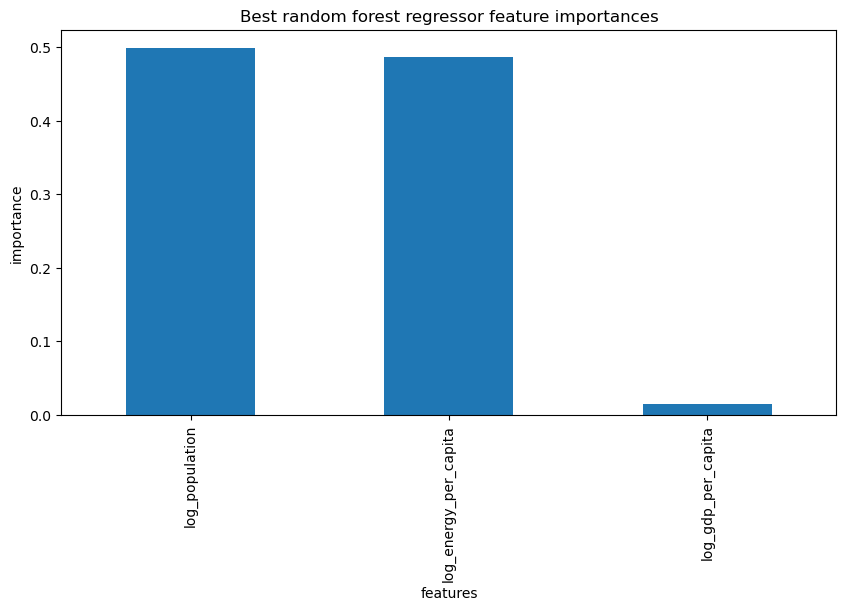

In [65]:
#Code task 27#
#Plot a barplot of the random forest's feature importances,
#assigning the `feature_importances_` attribute of 
#`rf_grid_cv.best_estimator_.named_steps.randomforestregressor` to the name `imps` to then
#create a pandas Series object of the feature importances, with the index given by the
#training data column names, sorting the values in descending order
plt.subplots(figsize=(10, 5))
imps = best_rf.named_steps.rf.feature_importances_
rf_feat_imps = pd.Series(imps, index=X_train.columns).sort_values(ascending=False)
rf_feat_imps.plot(kind='bar')
plt.xlabel('features')
plt.ylabel('importance')
plt.title('Best random forest regressor feature importances');

## 4.10 Final Model Selection<a id='4.10_Final_Model_Selection'></a>

Time to select your final model to use for further business modeling! It would be good to revisit the above model selection; there is undoubtedly more that could be done to explore possible hyperparameters.
It would also be worthwhile to investigate removing the least useful features. Gathering or calculating, and storing, features adds business cost and dependencies, so if features genuinely are not needed they should be removed.
Building a simpler model with fewer features can also have the advantage of being easier to sell (and/or explain) to stakeholders.
Certainly there seem to be four strong features here and so a model using only those would probably work well.
However, you want to explore some different scenarios where other features vary so keep the fuller 
model for now. 
The business is waiting for this model and you have something that you have confidence in to be much better than guessing with the average price.

Or, rather, you have two "somethings". You built a best linear model and a best random forest model. You need to finally choose between them. You can calculate the mean absolute error using cross-validation. Although `cross-validate` defaults to the $R^2$ [metric for scoring](https://scikit-learn.org/stable/modules/model_evaluation.html#scoring) regression, you can specify the mean absolute error as an alternative via
the `scoring` parameter.

### Model Performance Comparison

In [68]:
#Models Evaluation and Comparison
# define evaluation function

def evaluate(y_test, y_pred, model_name):
    print(f"{model_name}")
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("R2:", r2_score(y_test, y_pred))
    print("-"*30)

evaluate(y_test, test['ols_pred_scaled'], "OLS Fixed Effect Scaled Model")
evaluate(y_test, test['rf_pred_scaled'], "Random Forest Scaled Model")    

OLS Fixed Effect Scaled Model
RMSE: 0.2608433614678682
MAE: 0.19822632679929744
R2: 0.9851119753695557
------------------------------
Random Forest Scaled Model
RMSE: 0.33536866359675804
MAE: 0.22515323567562429
R2: 0.9753893852241933
------------------------------


## 4.11 Conclusion<a id='4.11_Conclusion'></a>

We evaluated Linear Regression Models (OLS in particular) and Random Forest Model. Feature Scaling was applied for both models. RMSE for fixed effect OLS model certainly looks better(0.26) compared to RMSE(0.34) for Random Forest Model. The fixed effects OLS model provides more interpretable coefficients and hence more insight into the drivers of CO2 emissions while Random Forest Model does a better job at predicting non linear relationships and interactions between features potentially improving predictive performance.

## 4.12 Save best model object from pipeline<a id='4.12_Save_best_model_object_from_pipeline'></a>

In [120]:
#Code task 28#
#This may not be "production grade ML deployment" practice, but adding some basic
#information to your saved models can save your bacon in development.
#Just what version model have you just loaded to reuse? What version of `sklearn`
#created it? When did you make it?
#Assign the pandas version number (`pd.__version__`) to the `pandas_version` attribute,
#the numpy version (`np.__version__`) to the `numpy_version` attribute,
#the sklearn version (`sklearn_version`) to the `sklearn_version` attribute,
#and the current datetime (`datetime.datetime.now()`) to the `build_datetime` attribute
#Let's call this model version '1.0'

In [69]:
# save the model

## 4.13 Summary<a id='4.13_Summary'></a>